# Lab 3: Trees and forests

## Decision and Machine Learning, Centrale Lille

In this lab, we use decision trees and random forests for a classification problem, with the implementations provided by `scikit-learn`. More precisely, we use a famous dataset: Fisher's iris (so famous that it has a Wikipedia page, see [here](https://en.wikipedia.org/wiki/Iris_flower_data_set)).

**Report by Ugo Roccamatisi.**


In [1]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

### Exercise 1 - Decision trees

**Q1.** Load the dataset using the proposed function. This loads the data into a dictionary-like structure (use `.keys()` to check its elements).

Then store the features in a variable X, and the class in a variable y.

What is this dataset about? How many features do we have? How many examples?

In [2]:
from sklearn.datasets import load_iris
iris=load_iris();print('Fields:',list(iris.keys()))
X=iris.data;y=iris.target
print('Observations, features:',X.shape,'classes:',iris.target_names.tolist(),'features:',iris.feature_names)

Fields: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Observations, features: (150, 4) classes: ['setosa', 'versicolor', 'virginica'] features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


**Answer.** The Iris dataset contains 150 flowers, 4 measurements (length and width of sepals and petals) and 3 species.

**Q2.** Split the dataset into a training set and a test set (80/20).

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=0,stratify=y)
print('Train/test:',X_train.shape,X_test.shape)

Train/test: (120, 4) (30, 4)


**Q3.** Fit a decision tree to the training set, and plot the resulting tree using the `plot_tree` function (add feature names and class names for readability).

Explain how to interpret the tree.

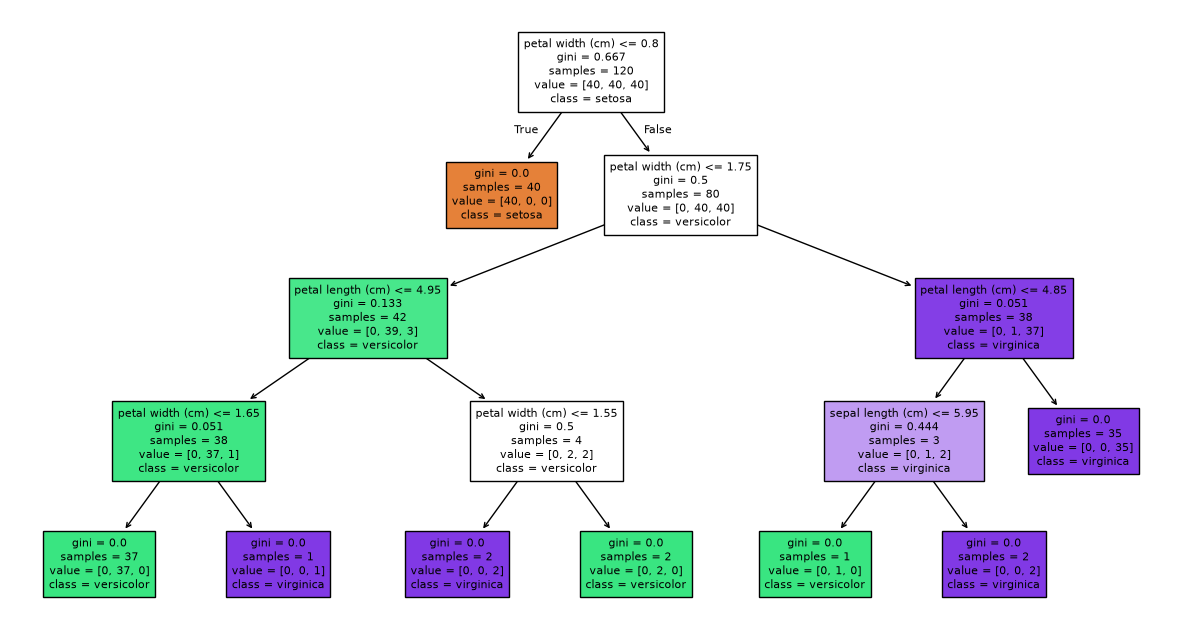

Depth and leaves: 4 8


In [4]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
tree=DecisionTreeClassifier(random_state=0).fit(X_train,y_train)
fig,ax=plt.subplots(figsize=(15,8));plot_tree(tree,feature_names=iris.feature_names,class_names=iris.target_names,filled=True,ax=ax,fontsize=8);plt.show()
print('Depth and leaves:',tree.get_depth(),tree.get_n_leaves())

**Answer.** At each node, go left if the condition `feature ≤ threshold` is true, right otherwise. `samples`, `value` and `class` give the number of examples, the counts per class and the majority class; the leaves give the prediction.

**Q4**. Check the performance of the decision tree on the test set.

In [5]:
from sklearn.metrics import accuracy_score,confusion_matrix
p=tree.predict(X_test)
print('Full tree accuracy:',accuracy_score(y_test,p))
print('Confusion matrix:\n',confusion_matrix(y_test,p))

Full tree accuracy: 0.9666666666666667
Confusion matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


**Answer.** The full tree reaches 96.7% accuracy on 30 flowers never seen during training, with a single error in the confusion matrix.

**Q5.** Now train two other decision trees, using only the petal features for the first one, and the sepal features for the other one.

In both cases, display the tree, and the decision regions (with the training set points). Also check their performance on the test set. Comment.

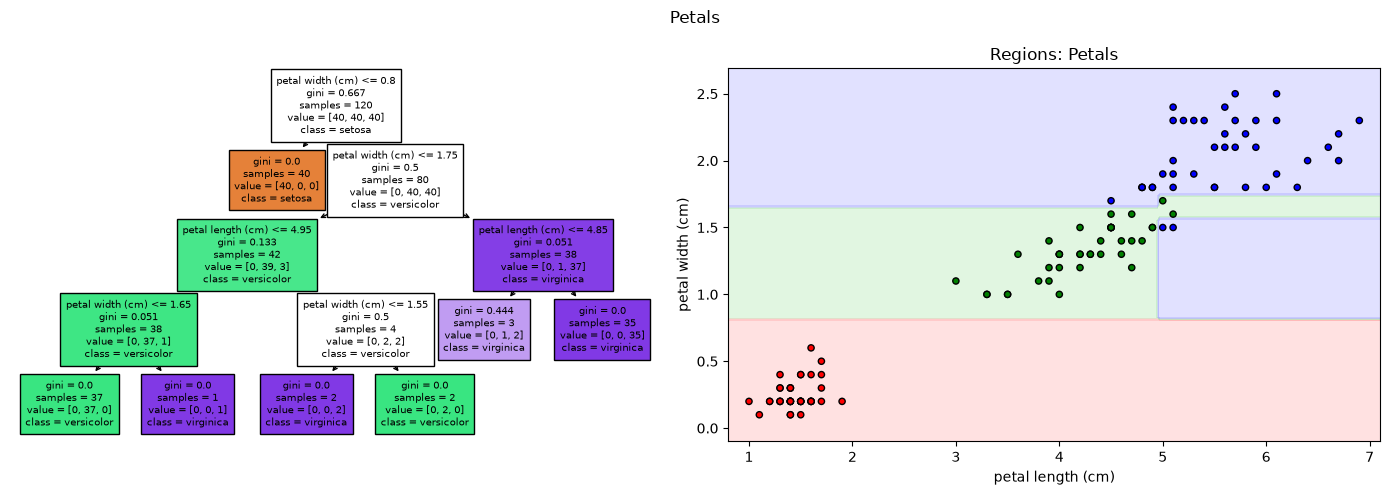

Petals: test accuracy=0.967, depth=4


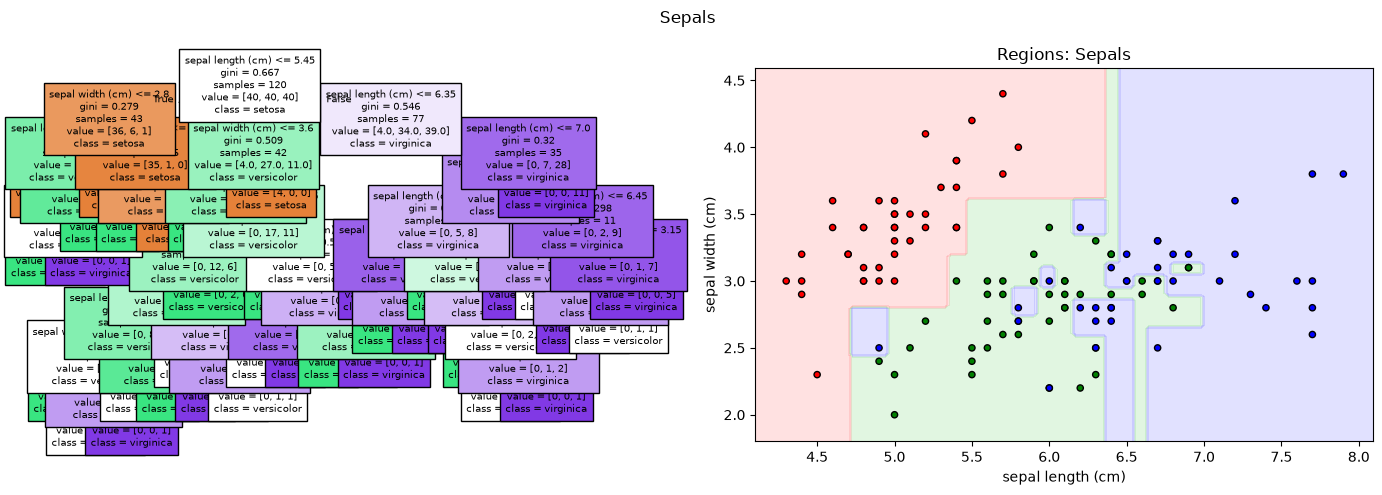

Sepals: test accuracy=0.600, depth=10


In [6]:
from matplotlib.colors import ListedColormap
subsets={'Petals':[2,3],'Sepals':[0,1]}
models={}
for title,cols in subsets.items():
    m=DecisionTreeClassifier(random_state=0).fit(X_train[:,cols],y_train)
    models[title]=m
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    plot_tree(m,feature_names=[iris.feature_names[i] for i in cols],class_names=iris.target_names,filled=True,ax=axes[0],fontsize=7)
    xx=X_train[:,cols];step=.03
    x0,x1=np.meshgrid(np.arange(xx[:,0].min()-.2,xx[:,0].max()+.2,step),np.arange(xx[:,1].min()-.2,xx[:,1].max()+.2,step))
    region=m.predict(np.c_[x0.ravel(),x1.ravel()]).reshape(x0.shape)
    axes[1].contourf(x0,x1,region,alpha=.25,cmap=ListedColormap(['#f88','#8d8','#88f']))
    axes[1].scatter(xx[:,0],xx[:,1],c=y_train,cmap=ListedColormap(['red','green','blue']),edgecolor='k',s=20)
    axes[1].set(xlabel=iris.feature_names[cols[0]],ylabel=iris.feature_names[cols[1]],title=f'Regions: {title}')
    fig.suptitle(title);fig.tight_layout();plt.show()
    print(f'{title}: test accuracy={m.score(X_test[:,cols],y_test):.3f}, depth={m.get_depth()}')

**Answer.** The colored regions show the successive axis-parallel splits. Petals separate the three species much better than sepals: 96.7% test accuracy with a depth-4 tree, against 60.0% for sepals with a depth-10 tree that overfits.

**Q6.** Check carefully the documentation for `DecisionTreeClassifier`, and explain how a decision tree could be regularized. What method from the lecture is not covered by scikit-learn ?

**Answer.** The tree can be regularized by limiting `max_depth`, increasing `min_samples_split` and `min_samples_leaf`, limiting `max_leaf_nodes`, setting `min_impurity_decrease`, or using `ccp_alpha` for cost-complexity pruning. Classic *reduced-error* pruning on a separate validation set is not directly implemented by `DecisionTreeClassifier`.

### Exercise 2 - Random forests

**Q1.** Now train a random forest on the whole dataset, using 200 trees, and setting the maximum depth of each tree to 3. Also add `oob_score = True`.

In [7]:
from sklearn.ensemble import RandomForestClassifier
# Fitted on the training set only, so that the test set remains available for a fair comparison.
forest=RandomForestClassifier(n_estimators=200,max_depth=3,oob_score=True,random_state=0,n_jobs=-1).fit(X_train,y_train)
print('Trees:',len(forest.estimators_),'OOB score:',forest.oob_score_)

Trees: 200 OOB score: 0.9583333333333334


**Q2.** Extract 5 differents trees from the forest and display them. Comment.

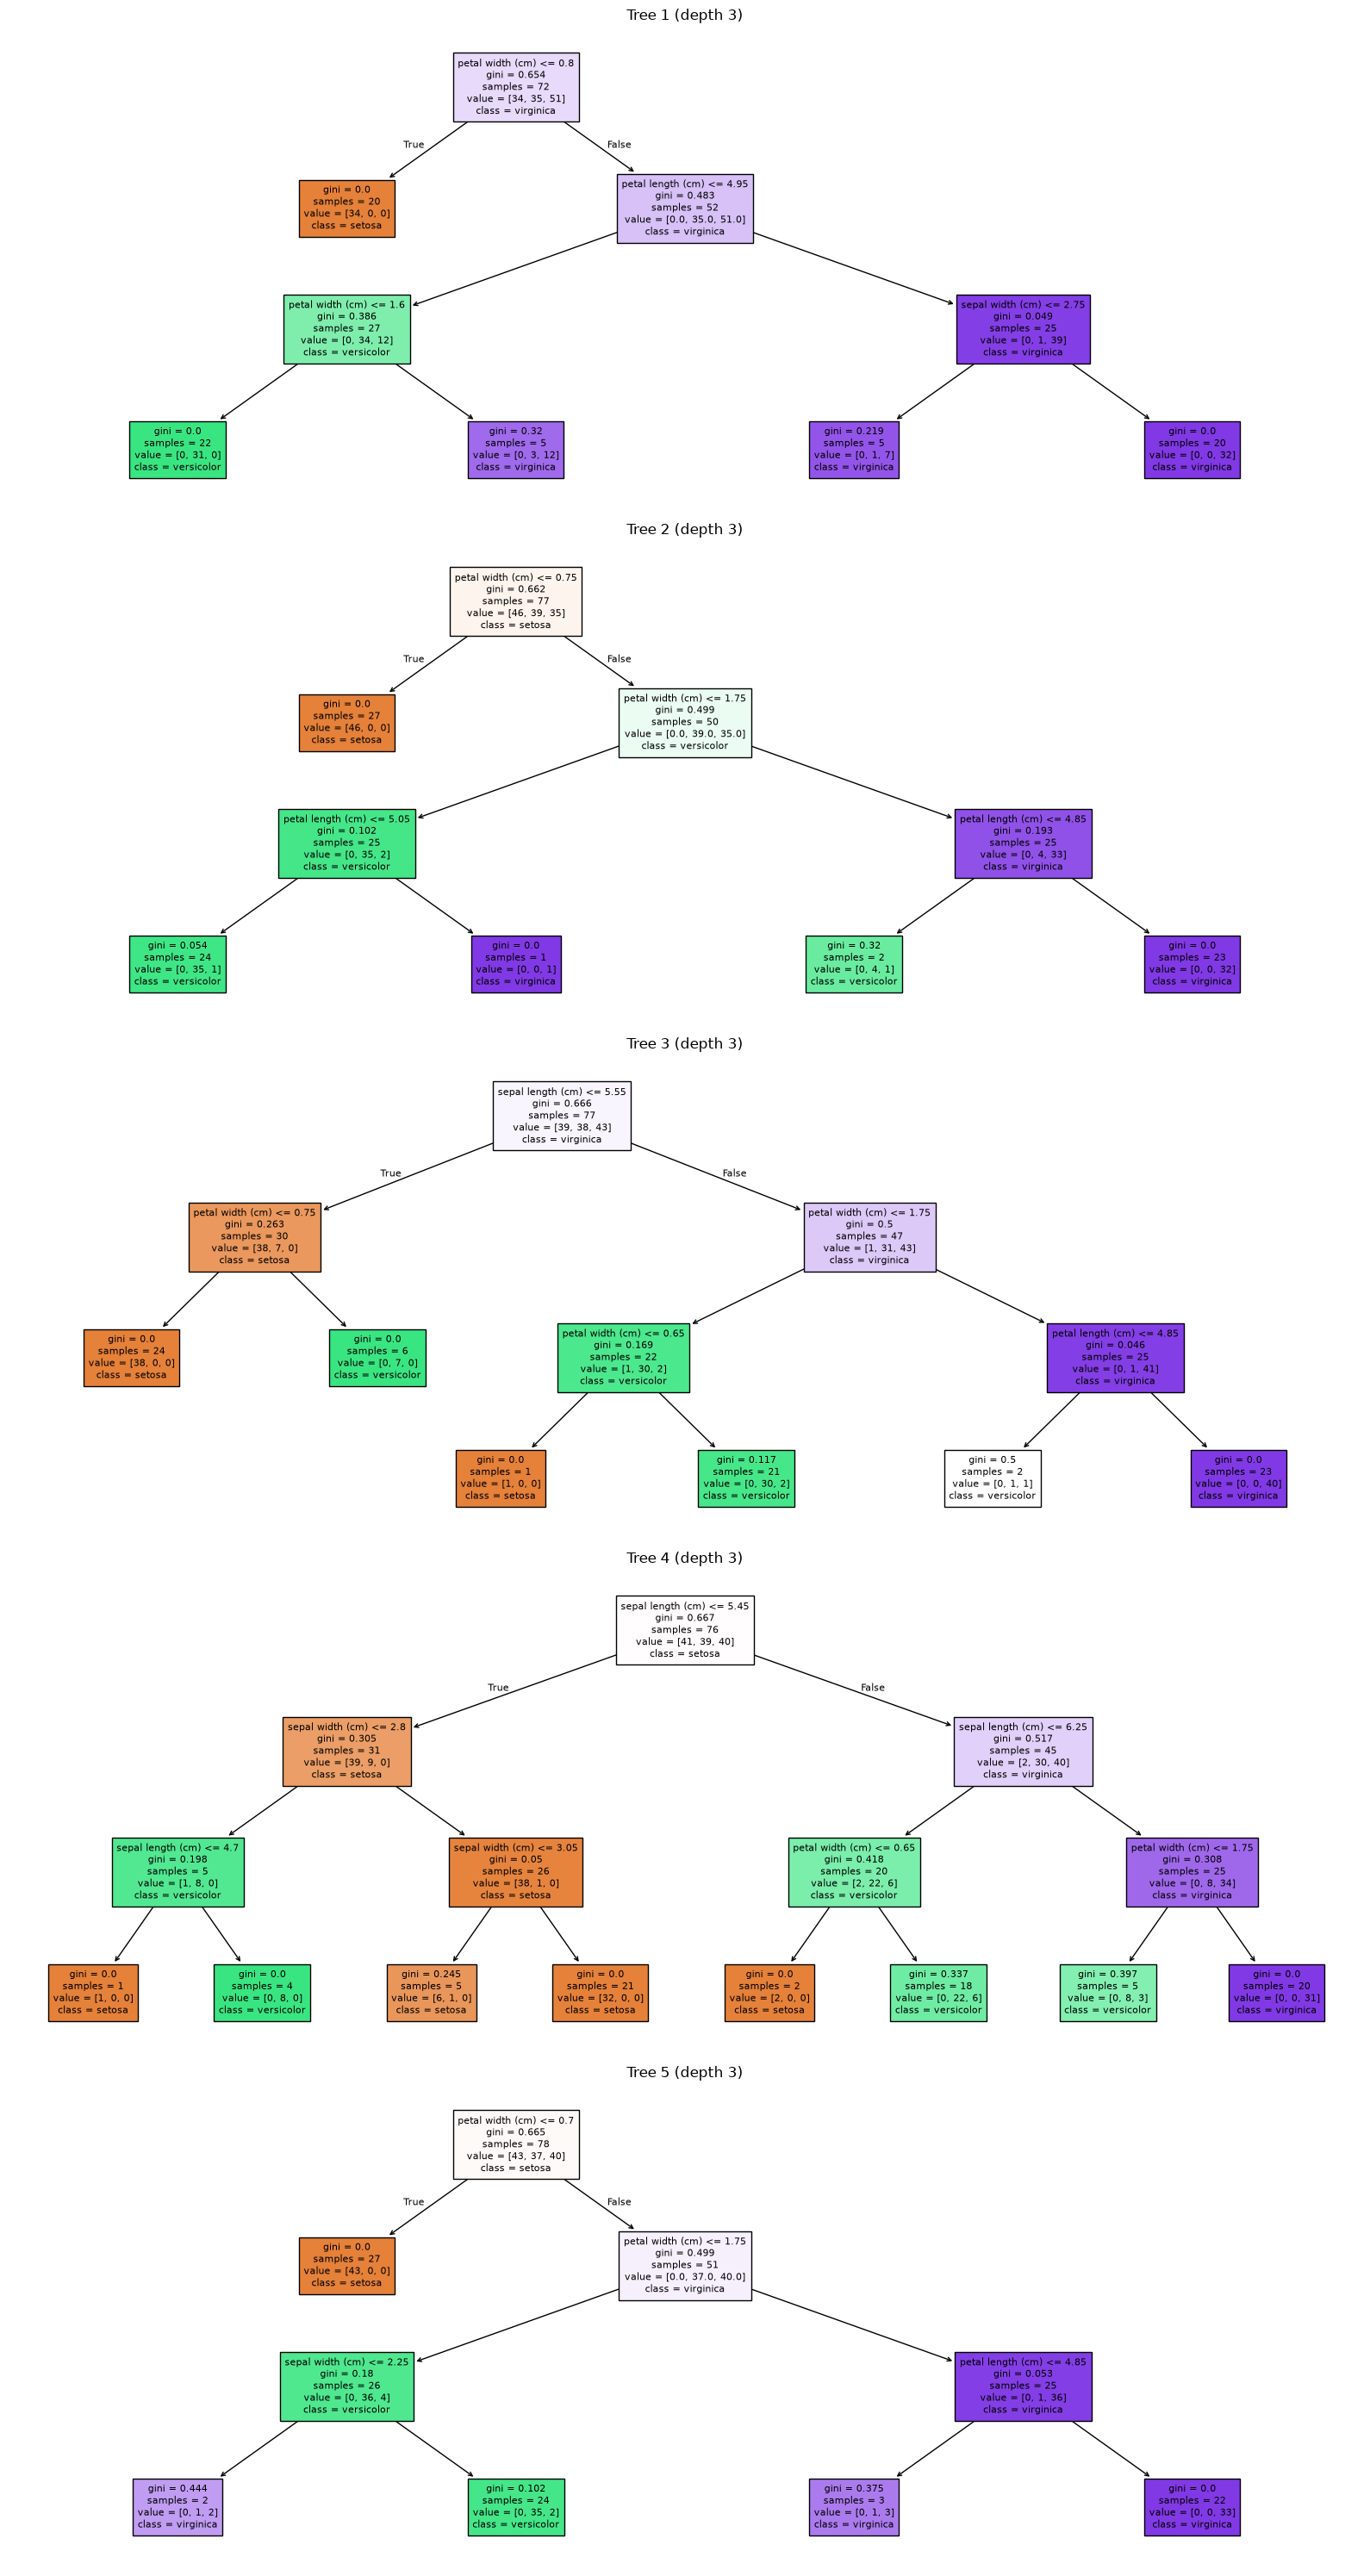

In [8]:
fig,axes=plt.subplots(5,1,figsize=(16,30))
for k,ax in enumerate(axes):
    t=forest.estimators_[k]
    plot_tree(t,feature_names=iris.feature_names,class_names=iris.target_names,filled=True,ax=ax,fontsize=8)
    ax.set_title(f'Tree {k+1} (depth {t.get_depth()})')
fig.tight_layout();plt.show()

**Q3.** Retrieve the feature importance for each feature. Which ones are the most important ? Does this match with what you observed in Q5 of Ex. 1 ?

In [9]:
for name,importance in sorted(zip(iris.feature_names,forest.feature_importances_),key=lambda item:-item[1]):print(f'{name}: {importance:.3f}')

petal width (cm): 0.475
petal length (cm): 0.401
sepal length (cm): 0.107
sepal width (cm): 0.018


**Q4.** Return the out-of-bag (OOB) error and recall how it is computed. Compare the performance of the random forest w.r.t. the decision trees studied in Ex. 1.

In [10]:
print(f'OOB error: {1-forest.oob_score_:.3f}')
print(f'Forest test accuracy: {forest.score(X_test,y_test):.3f}')
print(f'Full tree test accuracy: {tree.score(X_test,y_test):.3f}')
for label,cols in subsets.items():print(f'{label} tree test accuracy: {models[label].score(X_test[:,cols],y_test):.3f}')

OOB error: 0.042
Forest test accuracy: 0.933
Full tree test accuracy: 0.967
Petals tree test accuracy: 0.967
Sepals tree test accuracy: 0.600


**Answer Q2.** The five trees do not use exactly the same thresholds or features: each tree sees a bootstrap sample and, at each split, a random subset of the features.

**Answer Q3.** The importances sum to 1; the petal features dominate (0.475 and 0.401), consistent with the trees built on petal features only. Gini importance can be biased towards some features.

**Answer Q4.** For each tree, the observations left out of its bootstrap sample are evaluated by that tree; each observation gets a vote from the trees for which it is out of bag. `1 - oob_score_` is the error of these votes. The test scores above are directly comparable, since all models use the same train/test split. On only 30 test flowers, one error separates the forest (93.3%) from the single tree (96.7%), so the difference is not significant.